<a href="https://colab.research.google.com/github/cleitonhentges/Praticas-de-python/blob/Atividade---Visualiza%C3%A7%C3%A3o-de-Dados-em-Python/Atividade_A_Terceira_Etapa_Pr%C3%A9_Modelagem_Implementa%C3%A7%C3%A3o_de_Naive%20Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

df = pd.read_csv('/content/CREDIT_SCORE_PROJETO_PARTE1 (1).csv', delimiter=';')
df.head(20)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


In [38]:

#Checagem de valores nulos.
valores_nulos = df.isnull().sum()
print(valores_nulos)

#Estou deletando menores de 18 anos e pessoas que não cadastraram a idade.
df = df[df['Age'] >= 18].dropna(subset=['Age'])
df = df[df['Age'] != 'nan'].dropna(subset=['Age'])

valores_nulos = df.isnull().sum()
print(valores_nulos)

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64
Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64


In [39]:
import pandas as pd

#Checagem de dados incorretos

print(df['Gender'].unique())

print(df['Education'].unique())

print(df['Marital Status'].unique())

print(df['Number of Children'].unique())

print(df['Home Ownership'].unique())

print(df['Credit Score'].unique())

print(df['Age'].unique())

# Ganho anual
df['Income'] = df['Income'].str.replace('.', '').str.replace(',', '.').astype(float)


['Female' 'Male']
["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
['Single' 'Married']
[0 2 1 3]
['Rented' 'Owned']
['High' 'Average' 'Low']
[25. 30. 35. 40. 45. 50. 26. 31. 43. 48. 53. 29. 34. 39. 44. 49. 36. 41.
 46. 51. 27. 32. 37. 42. 47. 52. 28. 33. 38.]


In [40]:
#Traduzindo níveis de ensino
df['Education'].value_counts()
print(df['Education'].value_counts())

df['Education_Categoria'] = df['Education']

df['Education_Categoria'] = df['Education_Categoria'].replace({
    'Bachelor\'s Degree':'Bacharel',
    'Master\'s Degree':'Mestrado',
    'Doctorate':'Doutorado',
    'High School Diploma':'Diploma do Ensino Médio',
    'Associate\'s Degree':'Grau de Associado',
})

df['Education_Categoria'].value_counts()
print(df['Education_Categoria'].value_counts())


Education
Bachelor's Degree      34
Master's Degree        30
Doctorate              24
High School Diploma    22
Associate's Degree     20
Name: count, dtype: int64
Education_Categoria
Bacharel                   34
Mestrado                   30
Doutorado                  24
Diploma do Ensino Médio    22
Grau de Associado          20
Name: count, dtype: int64


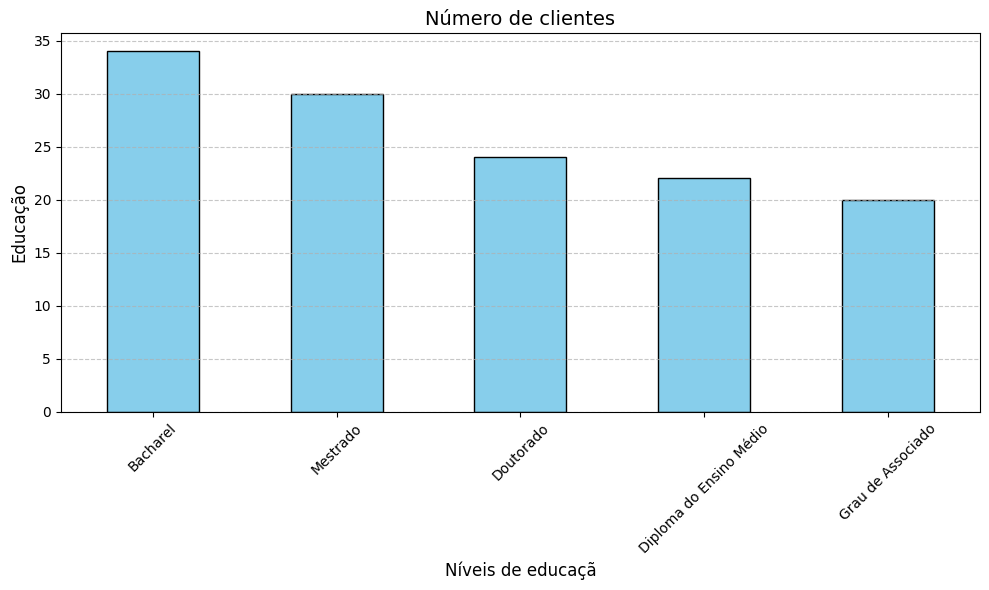

In [41]:
#Análise Univariada - Educação Acadêmica

Education_Categoria = df['Education_Categoria']

plt.figure(figsize=(10, 6))
df['Education_Categoria'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Número de clientes", fontsize=14)
plt.xlabel("Níveis de educaçã", fontsize=12)
plt.ylabel("Educação", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
df.describe(include='all')

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score,Education_Categoria
count,130.000000,130,130.000000,130,130,130.000000,130,130,130
unique,NaN,2,NaN,5,2,NaN,2,3,5
top,NaN,Female,NaN,Bachelor's Degree,Married,NaN,Owned,High,Bacharel
freq,NaN,68,NaN,34,68,NaN,86,88,34
mean,37.507692,NaN,84288.461538,NaN,NaN,0.661538,NaN,NaN,NaN
std,8.500110,NaN,33063.942361,NaN,NaN,0.902656,NaN,NaN,NaN
min,25.000000,NaN,25000.000000,NaN,NaN,0.000000,NaN,NaN,NaN
25%,30.000000,NaN,58125.000000,NaN,NaN,0.000000,NaN,NaN,NaN
50%,36.000000,NaN,82500.000000,NaN,NaN,0.000000,NaN,NaN,NaN
75%,45.000000,NaN,105000.000000,NaN,NaN,1.000000,NaN,NaN,NaN


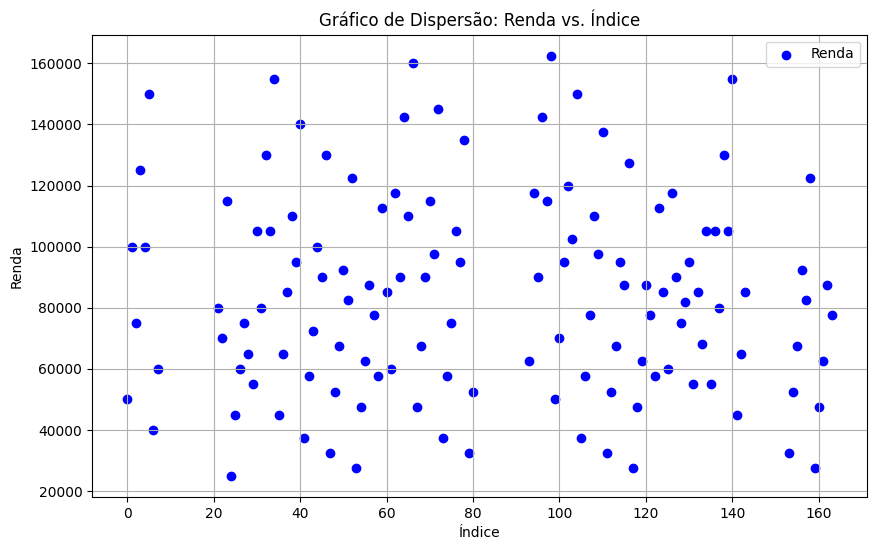

In [43]:
#Análise Univariada - Renda

x = df['Income'].index
y = df['Income']

plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['Income'], color='blue', label='Renda')
plt.xlabel('Índice')
plt.ylabel('Renda')
plt.title('Gráfico de Dispersão: Renda vs. Índice')
plt.legend()
plt.grid(True)


Não nota-se destacado nenhum outlier. variações padrões de salário.


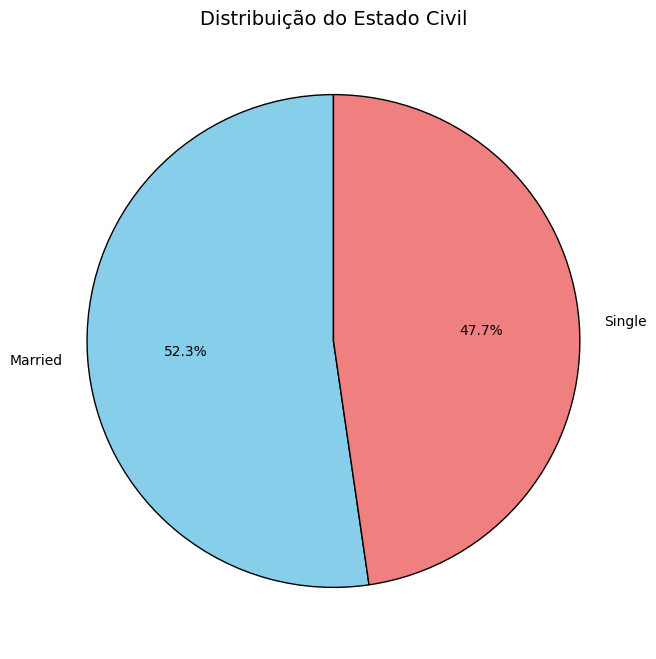

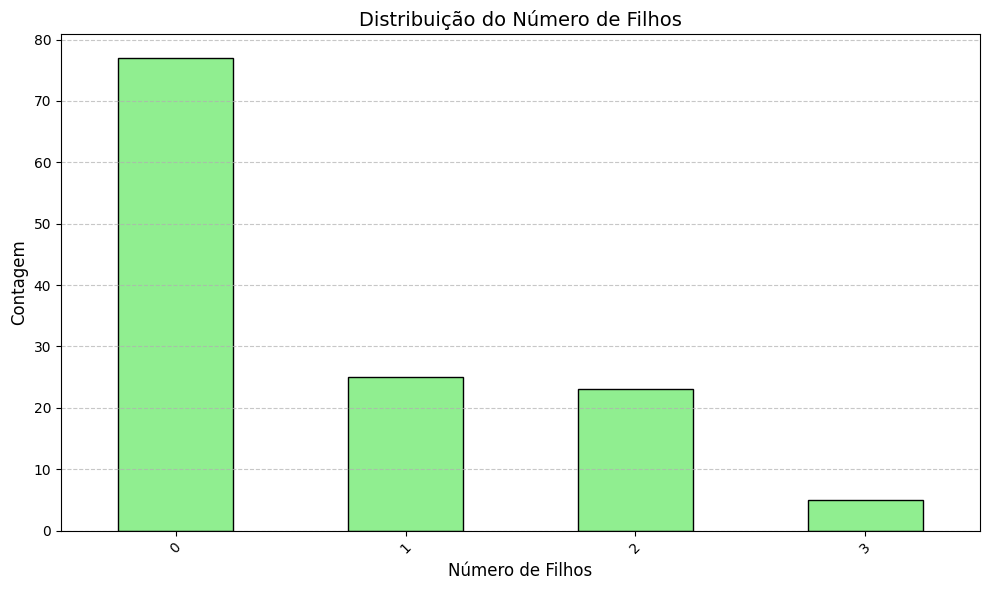

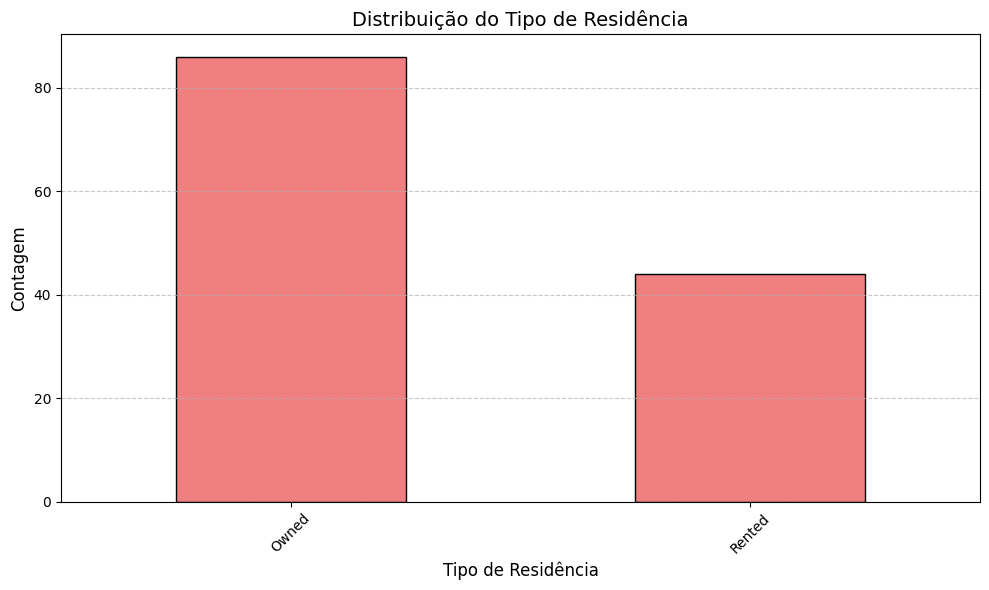

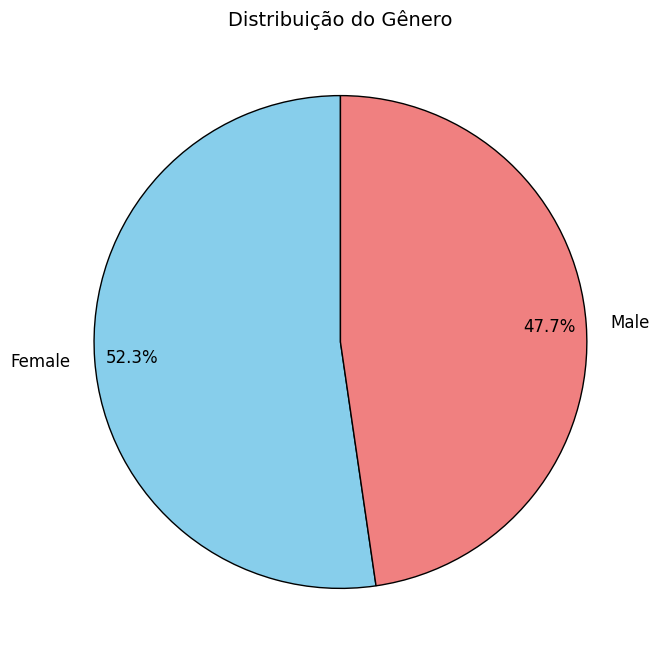

In [44]:

# Análise Univariada (Estado Civil)

plt.figure(figsize=(8, 8))
df['Marital Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral', 'lightgreen', 'gold'],
                                         startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Distribuição do Estado Civil", fontsize=14)
plt.ylabel("")
plt.show()

# Análise Univariada (Número de Filhos)
plt.figure(figsize=(10, 6))
df['Number of Children'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Distribuição do Número de Filhos", fontsize=14)
plt.xlabel("Número de Filhos", fontsize=12)
plt.ylabel("Contagem", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Análise Univariada (Tipo de Residência)

#df['Home Ownership'].value_counts()
#print(df['Home Ownership'].value_counts())

df['Home Ownership'] = df['Home Ownership'].replace({
    0: 'Alugada',
    1: 'Própria',
})

plt.figure(figsize=(10, 6))
df['Home Ownership'].value_counts().plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Distribuição do Tipo de Residência", fontsize=14)
plt.xlabel("Tipo de Residência", fontsize=12)
plt.ylabel("Contagem", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Análise Univariada (Genero)
plt.figure(figsize=(8, 8))
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue', 'lightcoral'],
    startangle=90,
    wedgeprops={'edgecolor': 'black'},
    pctdistance=0.85,
    textprops={'fontsize': 12}
)

plt.title("Distribuição do Gênero", fontsize=14)
plt.ylabel("")
plt.show()


# * **Estado Civil**: Observar a proporção entre os diferentes estados civis pode indicar tendências demográficas.
# * **Número de Filhos**:  Ajuda a entender o perfil familiar dos clientes, se há uma predominância de famílias com ou sem filhos, ou com muitos filhos.
# * **Tipo de Residência**:  Pode fornecer informações sobre o nível socioeconômico e estabilidade dos clientes.
# * **Gênero**: Permite analisar se há diferenças significativas entre homens e mulheres no contexto dos dados, podendo ser relevante para estratégias de marketing direcionadas.


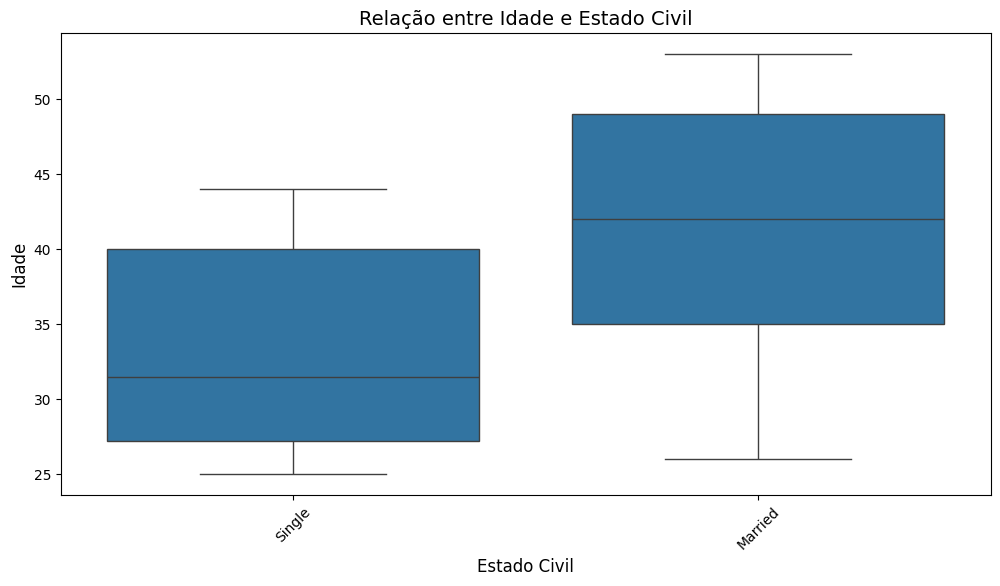

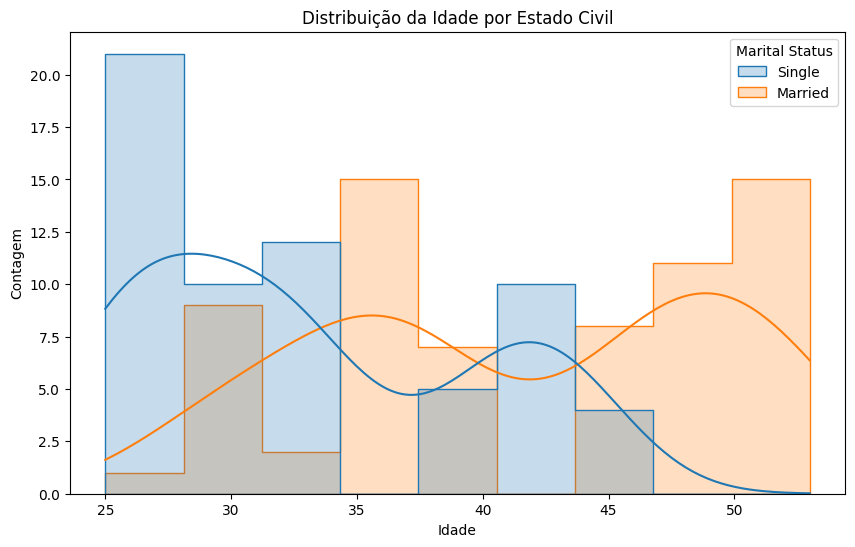

[1 0]


In [46]:

# Análise Bivariada (Idade vs estado civil)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Marital Status', y='Age', data=df)
plt.title('Relação entre Idade e Estado Civil', fontsize=14)
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Distribuição da idade por estado civil
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Marital Status', kde=True, element="step")
plt.title('Distribuição da Idade por Estado Civil')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()

#Calcular a correlação entre idade e estado civil
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Marital_Status_Num'] = le.fit_transform(df['Marital Status'])
print(df['Marital_Status_Num'].unique())

correlacao = df['Age'].corr(df['Marital_Status_Num'])
#print(f"A correlação entre idade e estado civil é: {correlacao}")



Pessoas mais velhas tem intuito de formar famílias enquanto pessoas mais novas buscam formação profissional e são mais abertos a novas experiências.

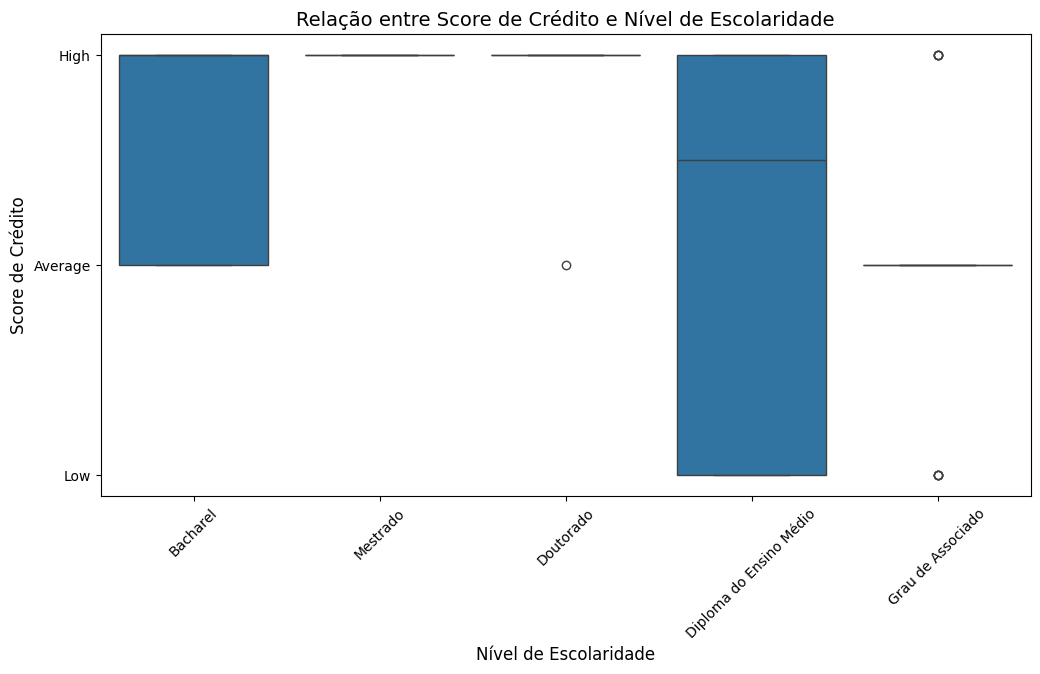

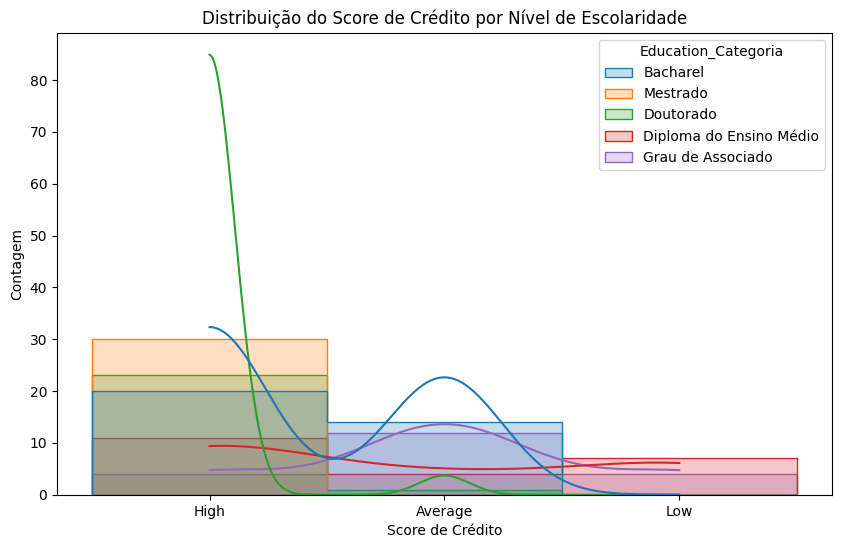

In [47]:
# Análise Bivariada (Score de Crédito vs escolaridade)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Education_Categoria', y='Credit Score', data=df)
plt.title('Relação entre Score de Crédito e Nível de Escolaridade', fontsize=14)
plt.xlabel('Nível de Escolaridade', fontsize=12)
plt.ylabel('Score de Crédito', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Distribuição do score de crédito por nível de escolaridade
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Credit Score', hue='Education_Categoria', kde=True, element="step")
plt.title('Distribuição do Score de Crédito por Nível de Escolaridade')
plt.xlabel('Score de Crédito')
plt.ylabel('Contagem')
plt.show()

Pessoas de ensino superior e mais tendem a ganhar mais e obter mais margem de crédito.

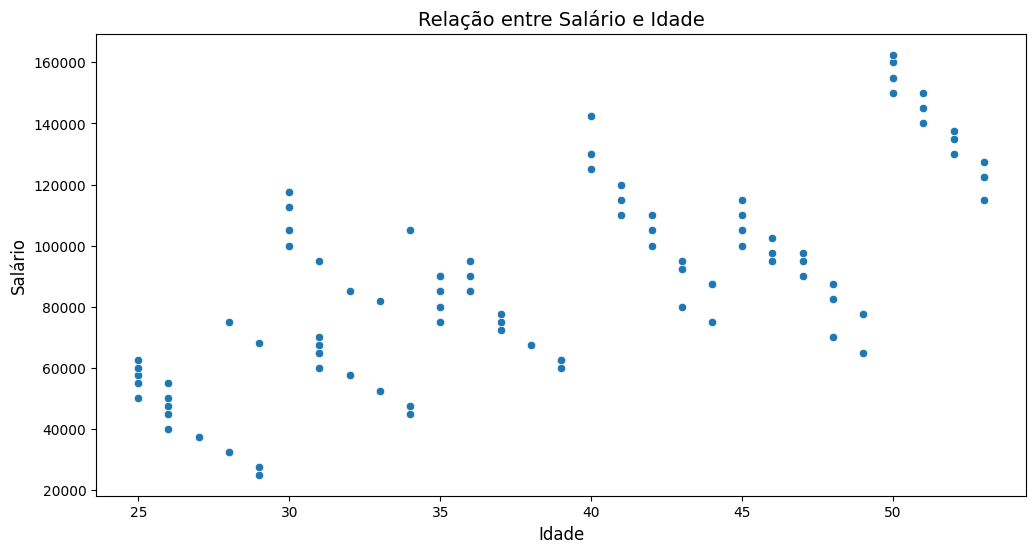

Correlação entre salário e idade: 0.6852131825495968


In [48]:
# Análise Bivariada (Salário vs idade)

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age', y='Income', data=df)
plt.title('Relação entre Salário e Idade', fontsize=14)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Salário', fontsize=12)
plt.show()

# Cálculo da correlação entre salário e idade
correlation = df['Age'].corr(df['Income'])
print(f"Correlação entre salário e idade: {correlation}")


Entre idades o salário pode haver uma disparidade e alguns se destacam pelo volume mas em uma visão geral é uma oscilação natural do mercado em ver que cargos mais altos não tem tantas vagas.

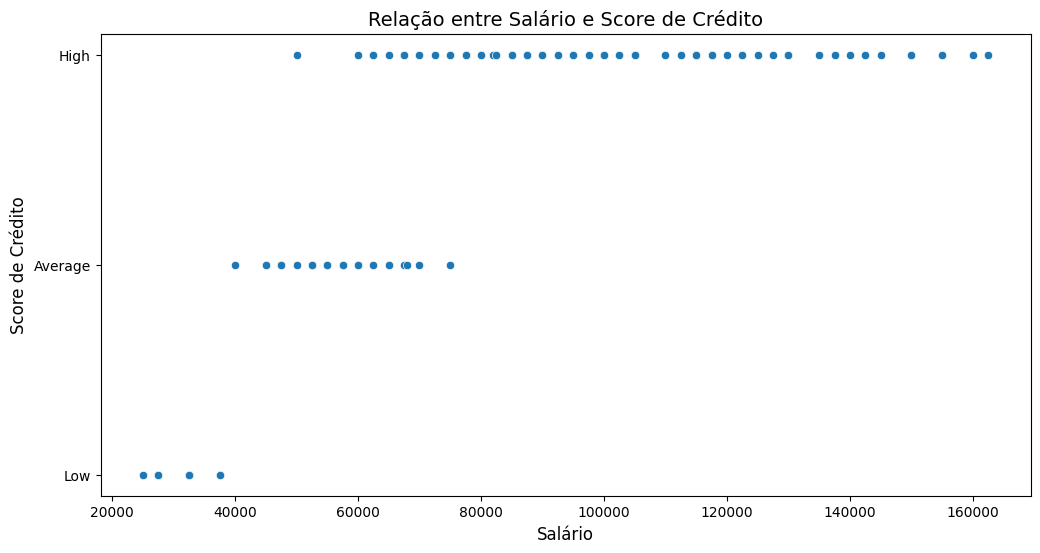

Correlação entre salário e Score de Crédito: 0.13029566289092967


In [49]:
# Análise Bivariada (Salário vs score de Crédito)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Income', y='Credit Score', data=df)
plt.title('Relação entre Salário e Score de Crédito', fontsize=14)
plt.xlabel('Salário', fontsize=12)
plt.ylabel('Score de Crédito', fontsize=12)
plt.show()


# Cálculo da correlação entre salário e Score de Crédito
# Convertendo Credit Score em valores numéricos;
if df['Credit Score'].dtype == object:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df['Credit_Score_Num'] = le.fit_transform(df['Credit Score'])
    correlation = df['Income'].corr(df['Credit_Score_Num'])
else:
    correlation = df['Income'].corr(df['Credit Score'])

print(f"Correlação entre salário e Score de Crédito: {correlation}")


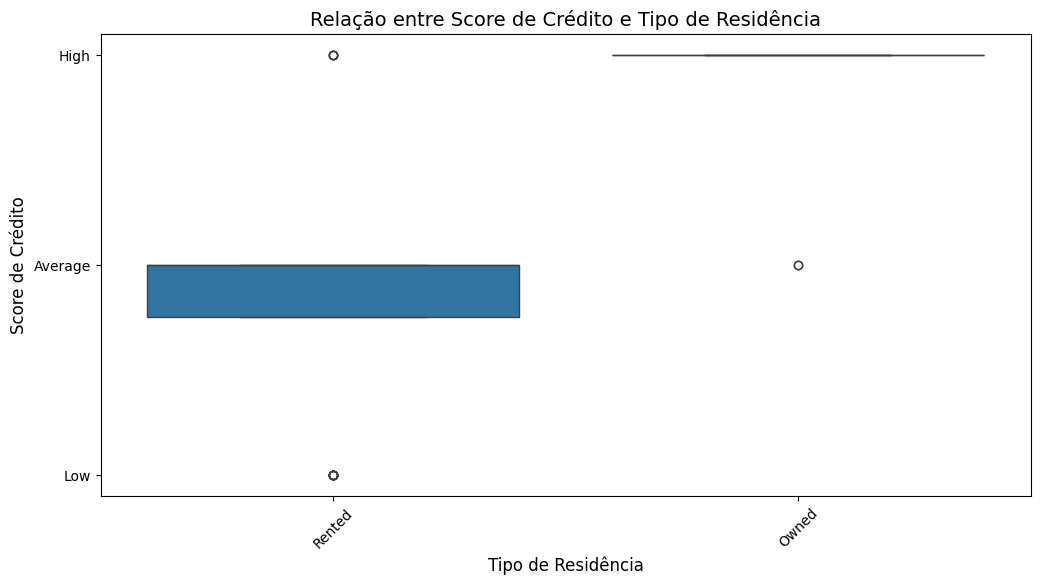

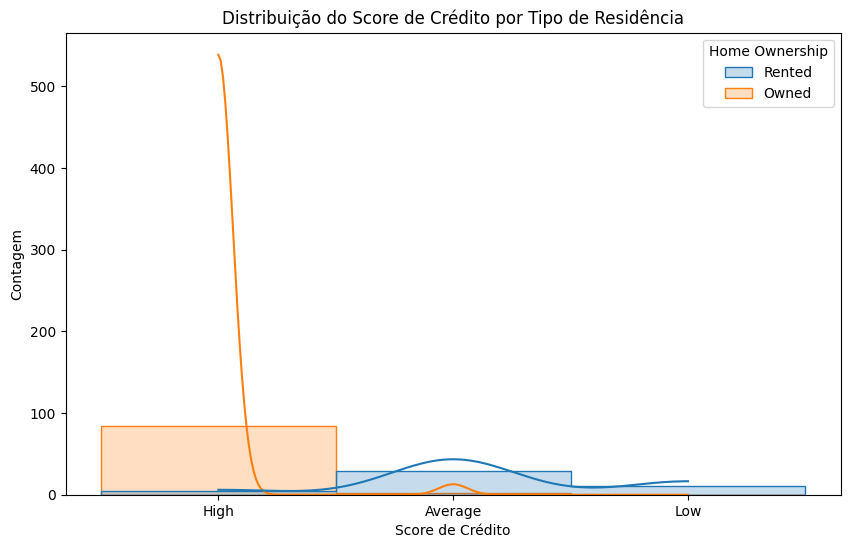

Correlação entre tipo de residência e Score de Crédito: 0.13029566289092967


In [50]:
# Análise Bivariada (Score de Crédito vs tipo de residência)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Home Ownership', y='Credit Score', data=df)
plt.title('Relação entre Score de Crédito e Tipo de Residência', fontsize=14)
plt.xlabel('Tipo de Residência', fontsize=12)
plt.ylabel('Score de Crédito', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Distribuição do score de crédito por tipo de residência
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Credit Score', hue='Home Ownership', kde=True, element="step")
plt.title('Distribuição do Score de Crédito por Tipo de Residência')
plt.xlabel('Score de Crédito')
plt.ylabel('Contagem')
plt.show()

# Calcular a correlação entre 'Home Ownership' e 'Credit Score'
# Converter a variável categórica 'Home Ownership' em numérica usando Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Home Ownership'] = le.fit_transform(df['Home Ownership'])

print(f"Correlação entre tipo de residência e Score de Crédito: {correlation}")

In [51]:
# Balanceamento de Classes
from imblearn.over_sampling import SMOTE

# Separar features (X) e target (y)
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

# Converter atributos categóricos em numéricos usando Label Encoding
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

# Aplicar SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Divisão em treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print("Shapes após o balanceamento e divisão:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Shapes após o balanceamento e divisão:
X_train: (211, 10)
X_test: (53, 10)
y_train: (211,)
y_test: (53,)


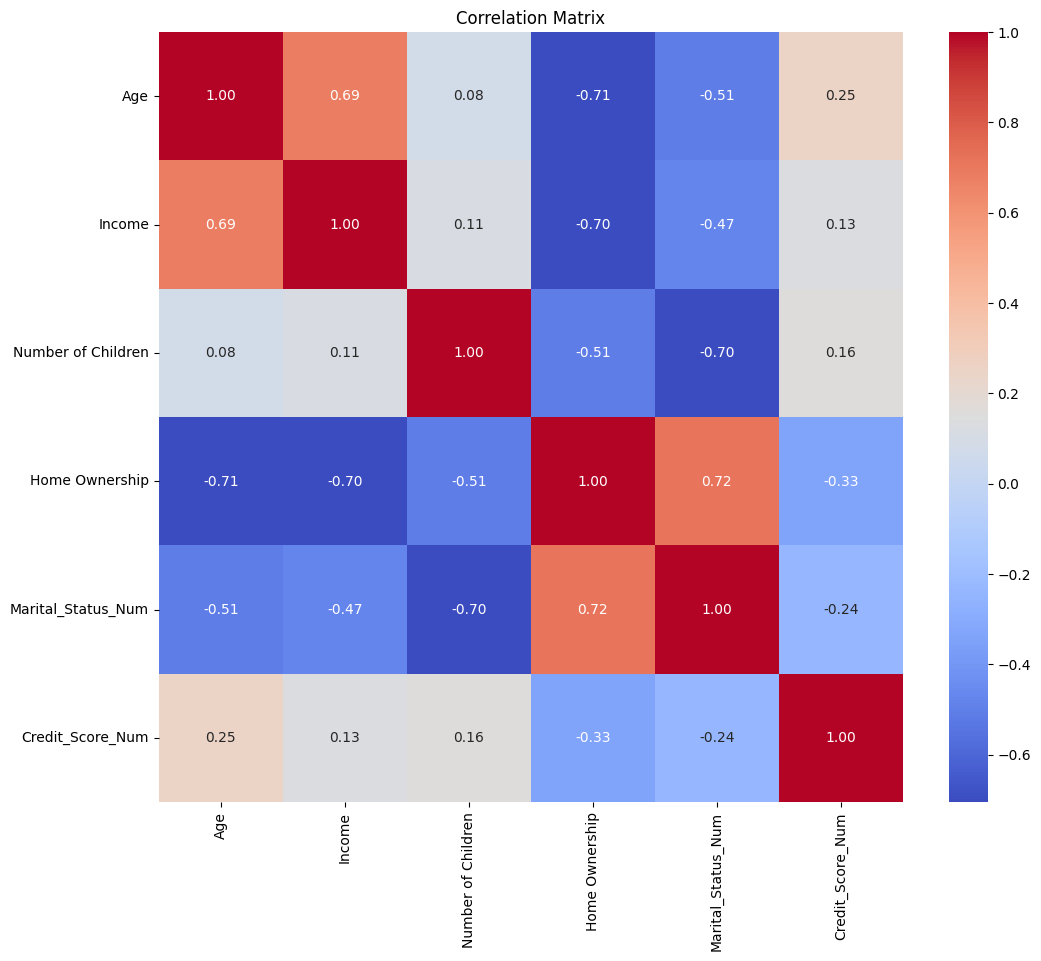

In [52]:
# Calculando a matriz de correlação
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

#Plotando a matriz de correlação usando um mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Existe uma alta correlação entre idade e salário e pessoas que ganham mais ou tem anos de experiência ou profissões que exigem formação acadêmica.
Pessoas mais velhas buscam formar uma família e logo adquirem uma casa própria, explicasse assim a alta correlação entre Marital Status e Home Ownership.

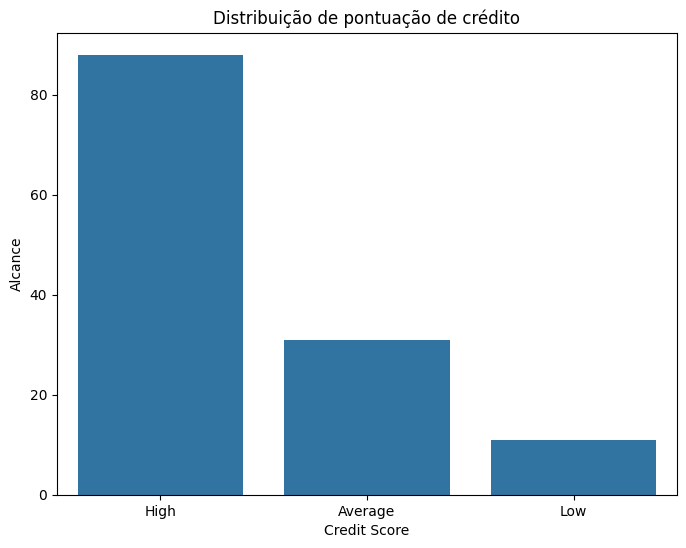

Credit Score
High       88
Average    31
Low        11
Name: count, dtype: int64


In [53]:
# Verifique o saldo da pontuação de crédito
plt.figure(figsize=(8, 6))
sns.countplot(x='Credit Score', data=df)
plt.title('Distribuição de pontuação de crédito')
plt.xlabel('Credit Score')
plt.ylabel('Alcance')
plt.show()

# Contagem de valores para cada categoria de pontuação de crédito
print(df['Credit Score'].value_counts())


In [54]:
from imblearn.over_sampling import RandomOverSampler

X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

#Convertendo recursos categóricos em numéricos usando Label Encoding
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

#Balanceado dados
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Distribução de balanceamento
print(pd.Series(y_resampled).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

#print("Shapes after balancing and splitting:")
#print("X_train:", X_train.shape)
#print("X_test:", X_test.shape)
#print("y_train:", y_train.shape)
#print("y_test:", y_test.shape)


Credit Score
High       88
Average    88
Low        88
Name: count, dtype: int64


A coluna 'Income' já está em um formato numérico.
Shapes after balancing and splitting:
X_train: (211, 10)
X_test: (53, 10)
y_train: (211,)
y_test: (53,)
Acurácia no conjunto de treinamento: 0.995260663507109
recall no conjunto de treinamento: 0.9951690821256038

Relatório de Classificação (Treinamento):
              precision    recall  f1-score   support

     Average       0.99      1.00      0.99        72
        High       1.00      0.99      0.99        69
         Low       1.00      1.00      1.00        70

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211

Acurácia no conjunto de teste: 1.0

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        16
        High       1.00      1.00      1.00        19
         Low       1.00      1.00      1.00        18

    accuracy           

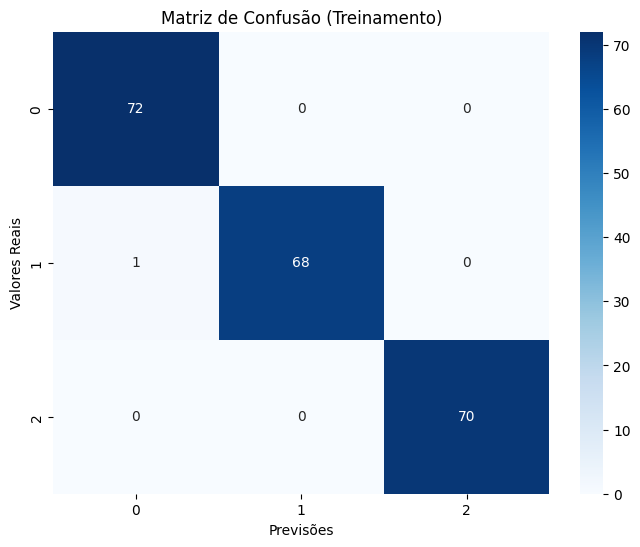

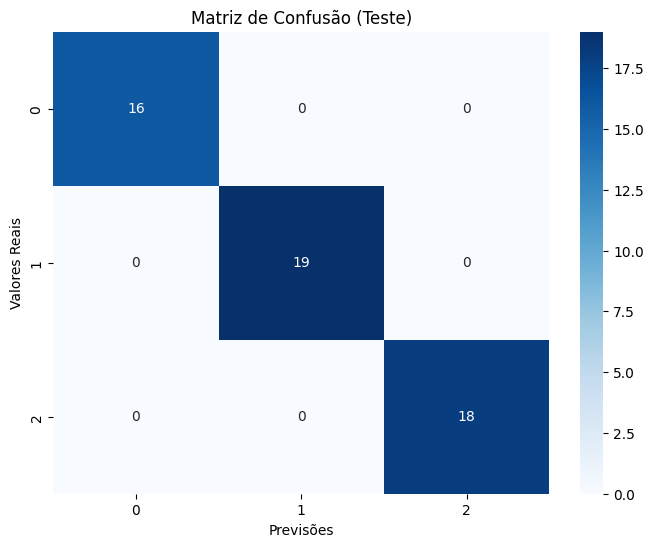

In [35]:
!pip install scikit-learn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import recall_score

# Etapas de pré-processamento
df = df[df['Age'] >= 18].dropna(subset=['Age'])
df = df[df['Age'] != 'nan'].dropna(subset=['Age'])

# Verificar se a coluna 'Income' já é do tipo numérico antes de tentar convertê-la
if df['Income'].dtype == object:  # Verificar se o tipo é 'object', o que geralmente indica strings em pandas
    df['Income'] = df['Income'].str.replace('.', '').str.replace(',', '.').astype(float)
else:
    print("A coluna 'Income' já está em um formato numérico.")
    # Se a coluna 'Income' já é do tipo numérico (int ou float)
    # Não é necessário aplicar a conversão de string

df['Education_Categoria'] = df['Education']
df['Education_Categoria'] = df['Education_Categoria'].replace({
    'Bachelor\'s Degree':'Bacharel',
    'Master\'s Degree':'Mestrado',
    'Doctorate':'Doutorado',
    'High School Diploma':'Diploma do Ensino Médio',
    'Associate\'s Degree':'Grau de Associado',
})

df['Home Ownership'] = df['Home Ownership'].replace({
    0: 'Alugada',
    1: 'Própria',
})
# Engenharia de recursos e codificação de rótulos
le = LabelEncoder()
df['Marital_Status_Num'] = le.fit_transform(df['Marital Status'])

if df['Credit Score'].dtype == object:
    le = LabelEncoder()
    df['Credit_Score_Num'] = le.fit_transform(df['Credit Score'])


# Separando base de teste
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

# Convertendo recursos categóricos em numéricos usando Label Encoding
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print("Shapes after balancing and splitting:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

#classificador Naive Bayes
nb_classifier = GaussianNB()

# Treinar o modelo com os dados de treinamento
nb_classifier.fit(X_train, y_train)

# Fazer previsões no conjunto de treinamento
y_pred_train = nb_classifier.predict(X_train)

# Modelo Avaliado
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treinamento: {accuracy_train}")

recall = recall_score(y_train, y_pred_train, average='macro')
print(f"recall no conjunto de treinamento: {recall}")

print("\nRelatório de Classificação (Treinamento):")
print(classification_report(y_train, y_pred_train))

#print("\nMatriz de Confusão (Treinamento):")
#print(confusion_matrix(y_train, y_pred_train))

# Fazer previsões no conjunto de teste
y_pred_test = nb_classifier.predict(X_test)

# Avaliar o modelo no conjunto de teste
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {accuracy_test}")

print("\nRelatório de Classificação (Teste):")
print(classification_report(y_test, y_pred_test))

#print("\nMatriz de Confusão (Teste):")
#print(confusion_matrix(y_test, y_pred_test))

# Matriz de confusão para o conjunto de treinamento
cm_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão (Treinamento)")
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.show()

# Matriz de confusão para o conjunto de teste
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão (Teste)")
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.show()

A acurácia do modelo no conjunto de teste é geralmente menor que no conjunto de treinamento. Isso é esperado, pois o modelo foi treinado nos dados de treinamento, e é natural que ele tenha um desempenho melhor nesses dados do que em dados de teste.
A diferença entre as acurácias de treino e teste indica o quanto o modelo está generalizando bem para dados que não viu durante o treinamento.


Se a diferença entre a acurácia de treinamento e teste for grande, isso sugere que o modelo pode estar sofrendo de overfitting.
“Overfitting ocorre quando o modelo se ajusta muito bem aos dados de treinamento mas não consegue generalizar para novos dados. Em outras palavras, o modelo está memorizando os dados de treinamento em vez de aprender as regras subjacentes.”
Em casos de overfitting, a acurácia no treino pode ser muito alta, mas a acurácia no teste será muito mais baixa.


Analisar o relatório de classificação e a matriz de confusão fornece uma visão mais completa do desempenho do modelo. O relatório de classificação nos dá precisão, recall, F1-score e suporte para cada classe.
A matriz de confusão fornece um detalhamento dos erros de classificação.

